# Run correlations for SVI before and after fixing errors
Compare correlations between CDC, HRRC, and UT before and after found errors and table adjustments.

## Description of Program
- program:    tu3svi4_6ev3_TablesFigures_2025-05-28
- task:       Set up correlation table for published paper
- Version:    2024-04-29
- 2024-06-13: Update HRRC with fixed Group Quarters data
- 2024-06-13: Add check for differences in SVI percentile and quartiles
- 2025-04-12: Update with 2020 SVI and only look at 1 versions
- 2025-04-16: Updated UTP to SVInsight for figures
- 2025-04-28: Focus on figures
- 2025-05-08: Update for current version of paper
- 2025-05-28: Add overall SVI correlations
- 2025-04-23: Replication Check
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 4 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import geopandas as gpd # For working with spatial data
import matplotlib.pyplot as plt # For plotting
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  1.1.1


## Set Provenance 

In [3]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\DesignSafe-Archive\\WorkNPR'

In [4]:
# Store Program Name for oSVInsightut files to have the same name and saved in the same directory
programname = "tu3svi4_6ev3_TablesFigures_2026-04-23"
# Make directory to save output
if not os.path.exists(programname):
   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [5]:
# read in original Version 1 data
sourceprogram = "tu3svi4_2av2_SVIoptions_2026-04-23"
sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_tract2020.csv"
# read in file and set ids as strings
Tract_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str})

sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_bg2020.csv"
BG_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str, 'BG2020': str})

C:\Users\nathanael99\AppData\Local\Temp\ipykernel_35984\2786741509.py:8: DtypeWarning: Columns (60) have mixed types. Specify dtype option on import or set low_memory=False.
  BG_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str, 'BG2020': str})


In [6]:
Tract_df.head()

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202081011,H202090012,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,airsite_tract,airsite_name
0,48189950200,6306913,0,0.26355,0.29075,0.05352,-15052.0,-0.00000,-59500.0,537.0,...,0.36285,97.0,0.844,4.0,4.0,1.0,0.0,48189.0,0.0,NaN
1,48219950400,12691656,5302,0.21368,0.40714,0.10448,-16492.0,-0.00000,-43800.0,637.0,...,0.29107,93.6,0.796,4.0,4.0,1.0,0.0,48219.0,0.0,NaN
2,48219950300,12186639,0,0.23184,0.27081,0.05693,-26892.0,-0.02171,-98500.0,860.0,...,0.12183,74.7,0.643,3.0,3.0,1.0,0.0,48219.0,0.0,NaN
3,48219950100,214157569,0,0.13342,0.36347,0.08676,-20890.0,-0.01476,-60200.0,616.0,...,0.28967,80.9,0.686,4.0,4.0,1.0,0.0,48219.0,0.0,NaN
4,48219950600,358638163,0,0.11713,0.31648,0.01074,-34403.0,-0.09363,-97100.0,814.0,...,0.18914,40.9,0.445,2.0,2.0,1.0,0.0,48219.0,0.0,NaN


In [7]:
Tract_df['TRACT2020'].astype(str).describe()

count            6896
unique           6896
top       48189950200
freq                1
Name: TRACT2020, dtype: object

In [8]:
BG_df.head()

,BG2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202090012,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,TRACT2020,airsite_bg,airsite_name
0,481539506003,9238641,0,0.12273,0.59882,0.02113,-41060.0,-0.02360,-73300.0,3501.0,...,72.0,0.613,3.0,3.0,1.0,0.0,48153.0,48153950600,0.0,NaN
1,481539506005,1070676551,101332,0.33274,0.08228,0.00000,-22793.0,-0.06962,-163500.0,663.0,...,22.6,0.334,1.0,1.0,1.0,0.0,48153.0,48153950600,0.0,NaN
2,481610004001,12766486,8204,0.30405,0.36973,0.05444,-17938.0,-0.00000,-78900.0,727.0,...,82.9,0.689,4.0,4.0,1.0,0.0,48161.0,48161000400,0.0,NaN
3,481610006001,153883256,544987,0.00000,0.50709,0.00000,-27873.0,-0.14894,-153900.0,661.0,...,27.6,0.365,2.0,2.0,1.0,0.0,48161.0,48161000600,0.0,NaN
4,481759602001,391287006,1789495,0.18392,0.56607,0.01743,-32928.0,-0.07495,-157900.0,393.0,...,53.0,0.502,3.0,3.0,1.0,0.0,48175.0,48175960200,0.0,NaN


In [9]:
BG_df[['TRACT2020','BG2020']].astype(str).describe()

,TRACT2020,BG2020
count,18638,18638
unique,6885,18638
top,nan,481539506003
freq,12,1


In [10]:
# read in table 1 details
sourceprogram = "tu3svi4_6av1_Table1_2026-04-23"
sourcefile = sourceprogram+"/"+sourceprogram+".csv"
table1_df = pd.read_csv(sourcefile)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname UTP
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


In [11]:
# read in table 1 details - manually updated from Table 1
sourcefile= "tu3svi4_6av1_Table1_2025-05-28_variables_to_compare.csv"
corrvars_df = pd.read_csv(sourcefile)
corrvars_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname UTP
0,2020,Denominator,Population,S0601,unknown,NaN,C202010020,H202010020,NaN
1,2020,Denominator,Households,DP02,unknown,NaN,C202010030,H202010030,NaN
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,NaN,B17017,NaN,NaN,H202020012,U202020013
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020


## Clean data

In [12]:
# rename newvarname UTP = newvarname SVInsight
table1_df.rename(columns={'newvarname UTP': 'newvarname SVInsight'}, inplace=True)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


In [13]:
# fill missing values with ''
corrvars_df.fillna('', inplace=True)
# rename newvarname UTP = newvarname SVInsight
corrvars_df.rename(columns={'newvarname UTP': 'newvarname SVInsight'}, inplace=True)

In [14]:
corrvars_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020


# Explore Results

### Correlations between key variabes

In [15]:
# loop through correlation vars and add correlation
table2_df = corrvars_df.copy()
for index, row in table2_df.iterrows():
    common_category = row['Common Category']
    cdc_varname = row['newvarname CDC']
    hrrc_varname = row['newvarname HRRC']
    SVInsight_varname = row['newvarname SVInsight']

    print(common_category, cdc_varname, hrrc_varname, SVInsight_varname)
    # check if cdc and hrrc varnames are not missing
    if cdc_varname != '' and hrrc_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[cdc_varname].corr(Tract_df[hrrc_varname])
        table2_df.loc[index, 'CDC-HRRC'] = corr
    # check if cdc and SVInsight varnames are not missing
    if cdc_varname != '' and SVInsight_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[cdc_varname].corr(Tract_df[SVInsight_varname])
        table2_df.loc[index, 'CDC-SVInsight'] = corr
    # check if hrrc and SVInsight varnames are not missing
    if hrrc_varname != '' and SVInsight_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[hrrc_varname].corr(Tract_df[SVInsight_varname])
        table2_df.loc[index, 'HRRC-SVInsight_tract'] = corr
        # get the correlation between the two variables
        corr = BG_df[hrrc_varname].corr(BG_df[SVInsight_varname])
        table2_df.loc[index, 'HRRC-SVInsight_BG'] = corr

Population C202010020 H202010020 
Households C202010030 H202010030 
Poverty C202020010 H202020010 U202020010
Elder Households in Poverty (HRRC) vs Households with Social Security Income (SVInsight)  H202020012 U202020013
Unemployed C202020020 H202020020 U202020020
Housing Cost Burden (CDC) vs Per Capita Income Past 12 Months (SVInsight) C202020031  U202020031
No Insurance C202020050  U202020050
No High School Diploma C202021010 H202021010 U202021010
Aged 65 or Older (CDC) vs Elder Households (HRRC) vs Population Under 5 and Over 65 (SVInsight) C202030010 H202030011 U202030020
Single-parent C202033010 H202033010 U202033010
Aged 17 or Younger (CDC) vs Children Under 5 Years Population (HRRC) C202033020 H202033025 
Minority C202060010 H202060010 
Native American, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U202060021
African American, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U202060022
Asian, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U2020

In [16]:
table2_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight,CDC-HRRC,CDC-SVInsight,HRRC-SVInsight_tract,HRRC-SVInsight_BG
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,,1.000000,NaN,NaN,NaN
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,,1.000000,NaN,NaN,NaN
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010,0.904353,0.905222,1.000000,1.000000
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013,NaN,NaN,0.397902,0.322845
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020,0.995160,0.999979,0.994963,0.997444


In [17]:
table2_df_v2 = table2_df.copy(deep=True)
# format columns
format_cols = ['CDC-HRRC', 'CDC-SVInsight', 'HRRC-SVInsight_tract', 'HRRC-SVInsight_BG']
table2_df_v2[format_cols] = table2_df_v2[format_cols].map("{:.2f}".format)
# convert to format string
table2_df_v2[format_cols] = table2_df_v2[format_cols].astype(str)
# replace 'nan' with ''
table2_df_v2[format_cols] = table2_df_v2[format_cols].replace('nan', '')
table2_df_v2.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight,CDC-HRRC,CDC-SVInsight,HRRC-SVInsight_tract,HRRC-SVInsight_BG
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,,1.00,,,
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,,1.00,,,
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010,0.90,0.91,1.00,1.00
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013,,,0.40,0.32
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020,1.00,1.00,0.99,1.00


In [18]:
# Save output as csv
table2_df_v2.to_csv(programname+"/"+programname+"_appendix2.csv", index=False)


### Explore with Scatter plots

In [19]:
def select_svi_vars(df, cat_vars, airsite_var):
    df_dict = {}
    # select southeast texas counties
    df_dict['SETX'] = df[df['SETX'] == 1].copy(deep=True)
    # convert to percentage
    for var in cat_vars:
        df_dict['SETX'][var] = df_dict['SETX'][var] * 100
    df_dict['sites'] = df_dict['SETX'][df_dict['SETX'][airsite_var] == 1].copy(deep=True)

    return df_dict

def axes_plot(num = 0, 
              axes = None,
              df_dict = {}, 
              svi1 = 'C202090012', 
              svi2 = 'H202090012', 
              title = 'CDC vs HRRC Census Tract', 
              label1 = 'CDC', 
              label2 = 'HRRC',
              legend1 = 'Tract',
              legend2 = 'Study Site Tract') -> plt.Axes:
    
    df = df_dict['SETX'].copy(deep=True)
    site_df = df_dict['sites'].copy(deep=True)

    # check if missing values
    if site_df[svi1].isnull().any():
        print(f"Missing values in {svi1} for study site tract")
        length = len(site_df[svi1])
        # drop missing values
        site_df = site_df.dropna(subset=[svi1])
        length2 = len(site_df[svi1])
        print(f"Missing values in {svi1} dropped {length - length2} rows")
    if site_df[svi2].isnull().any():
        print(f"Missing values in {svi2} for study site tract")
        length = len(site_df[svi2])
        # drop missing values
        site_df = site_df.dropna(subset=[svi2])
        length2 = len(site_df[svi2])
        print(f"Missing values in {svi2} dropped {length - length2} rows")

    # select west side sites if airsite_name starts with 'W'
    condition = site_df['airsite_name'].str.startswith('W')
    west_side_df = site_df[condition].copy(deep=True)
    # select east side sites if airsite_name starts with 'E'
    condition = site_df['airsite_name'].str.startswith('E')
    east_side_df = site_df[condition].copy(deep=True)

    ax = axes[num]

    # fix the min and max values for the axes to 1
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    # add a diagonal line from (0,0) to (100,100)
    ax.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=0.25)
    
    # Scatter plot for all of study area
    ax.scatter(df[svi1], df[svi2], alpha=1, marker='+', color='#b2df8a', label =legend1)
    ax.scatter(west_side_df[svi1], west_side_df[svi2], 
                    alpha=1,
                    marker='<',
                    color='#f1a340',
                    edgecolor='black',
                    linewidth=0.5,
                    s=100,
                    label = 'West '+legend2) # increase size of points
    ax.scatter(east_side_df[svi1], east_side_df[svi2], 
                    alpha=1,
                    marker='>',
                    color='#998ec3',
                    edgecolor='black',
                    linewidth=0.5,
                    s=100,
                    label = 'East '+legend2) # increase size of points
    # use airsite name to label points
    for i, row in west_side_df.iterrows():
        ax.text(row[svi1], row[svi2]-2, row['airsite_name'], fontsize=12, ha='center', va='top', weight='normal')
    for i, row in east_side_df.iterrows():
        ax.text(row[svi1], row[svi2]+2, row['airsite_name'], fontsize=12, ha='center', va='bottom', weight='normal')
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)
    ax.set_title(title)

    # add a letter in the top left corner of the plot
    letter = chr(97 + num)  # 97 is the ASCII code for 'a'
    ax.text(-4, 105, letter, fontsize=20, weight='bold', ha='left', va='top')

    # add correlation coefficient to the plot
    corr = df[svi1].corr(df[svi2])
    corr_text = f'Correlation: {corr:.2f}'
    ax.text(100, 20, corr_text, fontsize=12, ha='right', va='bottom', color='black')

    ax.legend(loc='lower right', fontsize=10)
    return ax


def generate_plot(svi_tract_dict,
                    svi_bg_dict, 
                    commonlabel,
                    cdc_varname, 
                    hrrc_varname, 
                    SVInsight_varname, 
                    label_cdc,
                    label_hrrc,
                    label_SVInsight):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes_plot(0, axes=axes, 
                df_dict = svi_tract_dict, 
                svi1=cdc_varname, svi2=hrrc_varname, 
                label1=label_cdc, label2=label_hrrc, 
                title='CDC/ATSDR SVI vs HRRC SVI Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(1, axes=axes, 
                df_dict = svi_tract_dict, 
                svi1=cdc_varname, svi2=SVInsight_varname, 
                label1=label_cdc, label2=label_SVInsight, 
                title='CDC/ATSDR SVI vs SVInsight Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(2, axes=axes, 
                df_dict = svi_tract_dict,  
                svi1=hrrc_varname, svi2=SVInsight_varname, 
                label1=label_hrrc, label2=label_SVInsight,
                title='HRRC SVI vs SVInsight Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(3, axes=axes, 
                df_dict = svi_bg_dict, 
                svi1=hrrc_varname, svi2=SVInsight_varname,
                label1=label_hrrc, label2=label_SVInsight, 
                title='HRRC SVI vs SVInsight Block Group', 
                legend1='SE TX Block Group',
                legend2='Study Site Block Group')


    # save figure
    outputfile = os.path.join(programname, f'{programname}_{commonlabel}.jpeg')
    plt.savefig(outputfile, dpi=600, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

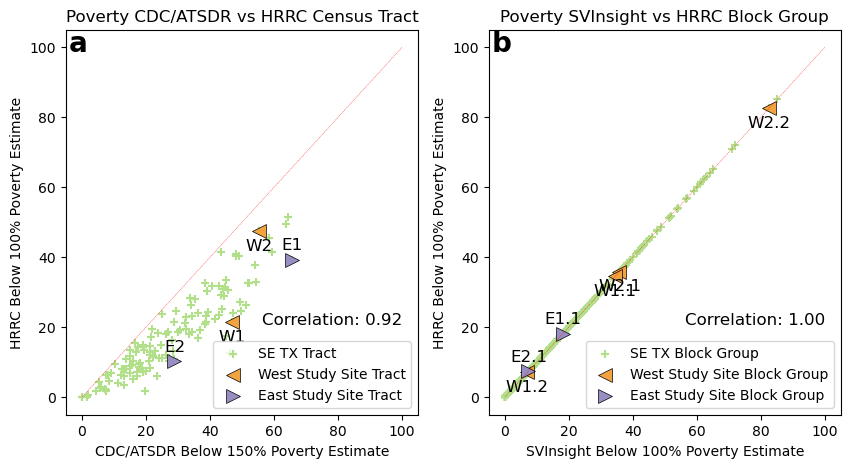

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

cat_vars_tract = ['C202020010', 'H202020010']
svi_tract_dict = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')

label1 = 'CDC/ATSDR Below 150% Poverty Estimate'
label2 = 'HRRC Below 100% Poverty Estimate'

axes_plot(0, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='C202020010', svi2='H202020010', 
            label1=label1, label2=label2, 
            title='Poverty CDC/ATSDR vs HRRC Census Tract', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

cat_vars_bg = ['U202020010', 'H202020010']
svi_bg_dict = select_svi_vars(BG_df, cat_vars_bg, airsite_var='airsite_bg')

label1 = 'SVInsight Below 100% Poverty Estimate'
label2 = 'HRRC Below 100% Poverty Estimate'

axes_plot(1, axes=axes, 
            df_dict = svi_bg_dict, 
            svi1='U202020010', svi2='H202020010', 
            label1=label1, label2=label2, 
            title='Poverty SVInsight vs HRRC Block Group', 
            legend1='SE TX Block Group',
            legend2='Study Site Block Group')

# save figure
outputfile = os.path.join(programname, f'{programname}_figure3.jpeg')
plt.savefig(outputfile, dpi=600, bbox_inches='tight')

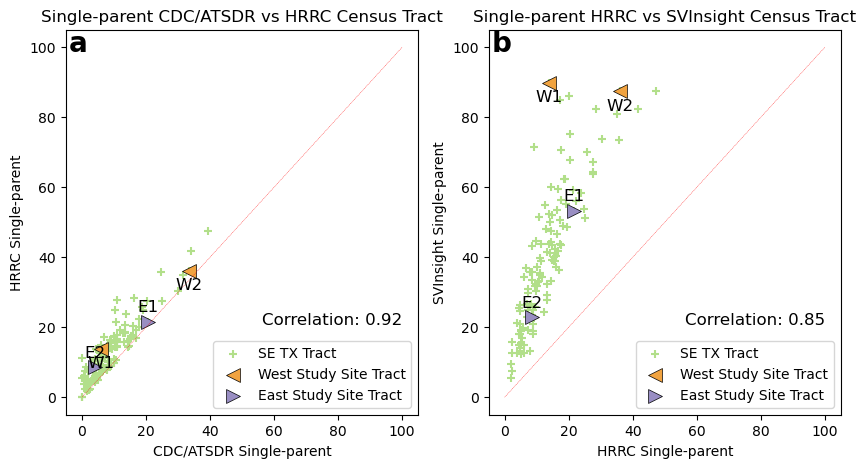

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

cat_vars_tract = ['C202033010', 'H202033010']
svi_tract_dict = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')

label1 = 'CDC/ATSDR Single-parent'
label2 = 'HRRC Single-parent'

axes_plot(0, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='C202033010', svi2='H202033010', 
            label1=label1, label2=label2, 
            title='Single-parent CDC/ATSDR vs HRRC Census Tract', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

cat_vars_tract = ['H202033010', 'U202033010']
svi_tract_dict = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')

label1 = 'HRRC Single-parent'
label2 = 'SVInsight Single-parent'

axes_plot(1, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='H202033010', svi2='U202033010', 
            label1=label1, label2=label2, 
            title='Single-parent HRRC vs SVInsight Census Tract', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

# save figure
outputfile = os.path.join(programname, f'{programname}_figure4.jpeg')
plt.savefig(outputfile, dpi=600, bbox_inches='tight')

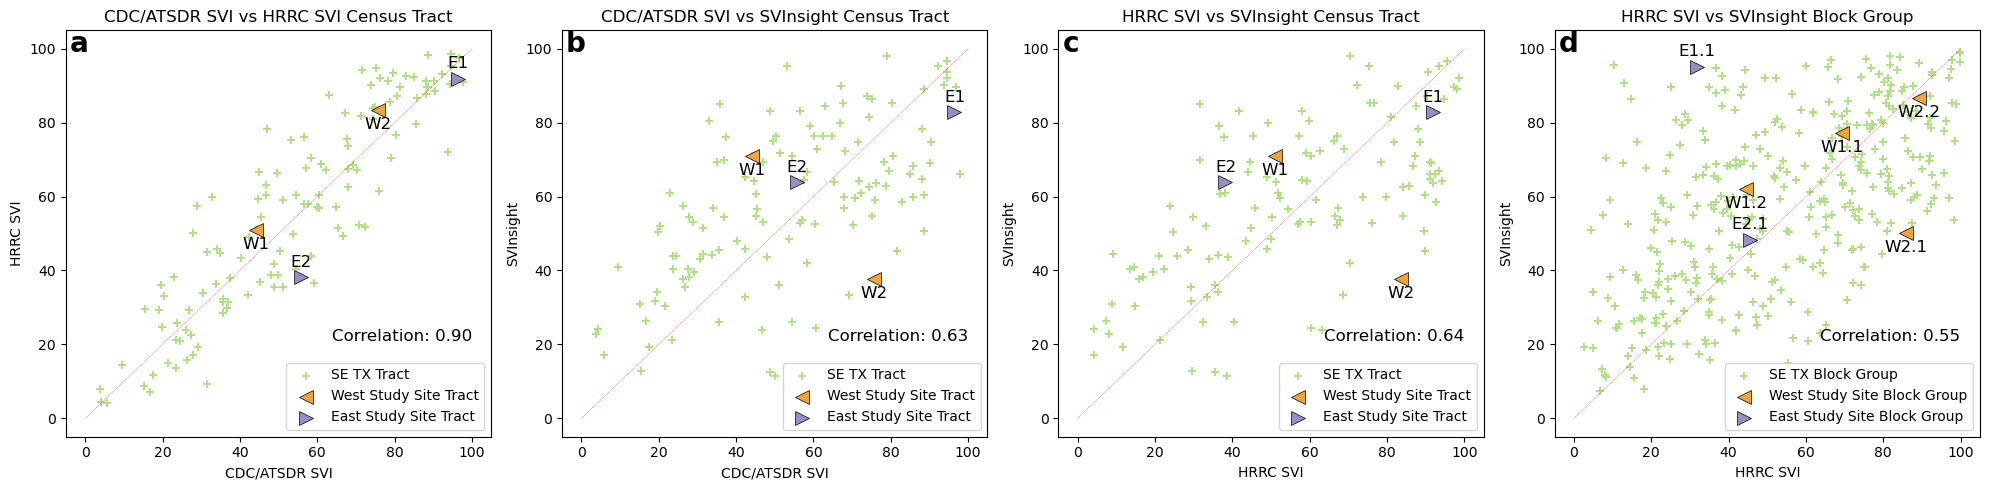

<Figure size 640x480 with 0 Axes>

In [22]:
cat_vars_tract = ['C202090012', 'H202090012', 'U202090012']
cat_vars_bg = ['H202090012', 'U202090012']

def select_svi_vars_v2(df, airsite_var):
    df_dict = {}
    # select southeast texas counties
    df_dict['SETX'] = df[df['SETX'] == 1].copy(deep=True)

    df_dict['sites'] = df_dict['SETX'][df_dict['SETX'][airsite_var] == 1].copy(deep=True)

    return df_dict

svi_tract_dict = select_svi_vars_v2(Tract_df, airsite_var='airsite_tract')
svi_bg_dict = select_svi_vars_v2(BG_df, airsite_var='airsite_bg')

generate_plot(svi_tract_dict, 
              svi_bg_dict, 
              commonlabel = "SVIoptions",
              cdc_varname = 'C202090012',
              hrrc_varname = 'H202090012',
              SVInsight_varname = 'U202090012',
              label_cdc = 'CDC/ATSDR SVI',
              label_hrrc = 'HRRC SVI',
              label_SVInsight = 'SVInsight')

# save figure
outputfile = os.path.join(programname, f'{programname}_figure5.jpeg')
plt.savefig(outputfile, dpi=600, bbox_inches='tight')

In [23]:
# describe cat_vars_tract
Tract_df[cat_vars_tract].describe().T

,count,mean,std,min,25%,50%,75%,max
C202090012,6828.0,49.999467,28.873818,0.000,24.9975,50.000,75.0025,100.0
H202090012,6884.0,50.013350,28.828328,0.000,25.0000,50.100,75.0000,100.0
U202090012,6825.0,50.007326,28.869628,0.015,25.0110,50.007,75.0040,100.0


In [24]:
# describe cat_vars_tract
BG_df[cat_vars_bg].describe().T

,count,mean,std,min,25%,50%,75%,max
H202090012,18626.0,49.958145,28.854574,0.000,24.90000,49.9000,75.0000,100.0
U202090012,18418.0,50.002715,28.868297,0.005,25.00425,50.0025,75.0015,100.0


In [25]:
# select southeast texas counties
svi_tract_gdf_setx = Tract_df[Tract_df['SETX'] == 1].copy(deep=True)
svi_tract_gdf_airsite = svi_tract_gdf_setx[svi_tract_gdf_setx['airsite_tract'] == 1].copy(deep=True)
# adjust the US benchmark values to be percentages
svi_tract_gdf_airsite['C202090011'] = svi_tract_gdf_airsite['C202090011'] * 100
table4_pt1 = svi_tract_gdf_airsite[['TRACT2020','ALAND','H202010020','C202090011','C202090012','H202090012','U202090012','airsite_name']].copy(deep=True)

# convert ALAND to square km
convert_sq_m_to_sq_km = 1e6
table4_pt1['ALAND'] = table4_pt1['ALAND'] / convert_sq_m_to_sq_km

# round all to 1 decimal place
table4_pt1 = table4_pt1.round(2)

# rename columns 
table4_pt1.rename(columns={ 'C202090012': 'CDC/ATSDR SVI: TX Benchmark', 
                            'H202090012': 'HRRC SVI',
                            'U202090012': 'SVInsight SVI',
                            'TRACT2020': 'Tract ID',
                            'airsite_name' : 'Study Site'}, inplace=True)
# move airsite_name to the first column
table4_pt1 = table4_pt1[['Study Site', 'Tract ID', 
                             'CDC/ATSDR SVI: TX Benchmark', 
                            'HRRC SVI', 'SVInsight SVI']]
# sort by airsite_name
table4_pt1 = table4_pt1.sort_values(by=['Study Site'])
table4_pt1 = table4_pt1.T
# set the first row as the header
table4_pt1.columns = table4_pt1.iloc[0]
# drop the first row    
table4_pt1 = table4_pt1.drop(table4_pt1.index[0])
table4_pt1 = table4_pt1.drop(table4_pt1.index[0])
# reset the index
table4_pt1 = table4_pt1.reset_index()
# rename the index column
table4_pt1.rename(columns={'index': 'SVI'}, inplace=True)

# add W1 and W2 together
table4_pt1['West Avg'] = (table4_pt1['W1'] + table4_pt1['W2'])/2
# average E1 and E2 together
table4_pt1['East Avg'] = (table4_pt1['E1'] + table4_pt1['E2'])/2
# calculate the difference between East and West
table4_pt1['Difference Avg'] = table4_pt1['West Avg'] - table4_pt1['East Avg']

# format average columns to 1 decimal place
table4_pt1['East Avg'] = table4_pt1['East Avg'].map("{:.1f}".format)
table4_pt1['West Avg'] = table4_pt1['West Avg'].map("{:.1f}".format)
# format difference columns to 1 decimal place
table4_pt1['Difference Avg'] = table4_pt1['Difference Avg'].map("{:.1f}".format)

# reorder columns
table4_pt1 = table4_pt1[['SVI', 'W1', 'W2', 'E1', 'E2', 'West Avg', 'East Avg', 'Difference Avg']]

# format all columns to 1 decimal place
table4_pt1[table4_pt1.columns[1:]] = table4_pt1[table4_pt1.columns[1:]].map(lambda x: "{:.1f}".format(float(x)))
table4_pt1

Study Site,SVI,W1,W2,E1,E2,West Avg,East Avg,Difference Avg
0,CDC/ATSDR SVI: TX Benchmark,44.2,75.6,96.5,55.8,59.9,76.1,-16.2
1,HRRC SVI,51.0,83.5,91.9,38.2,67.2,65.1,2.2
2,SVInsight SVI,71.1,37.7,82.8,63.9,54.4,73.4,-19.0


In [26]:
# select southeast texas counties
svi_bg_gdf_setx = BG_df[BG_df['SETX'] == 1].copy(deep=True)
svi_bg_gdf_airsite = svi_bg_gdf_setx[svi_bg_gdf_setx['airsite_bg'] == 1].copy(deep=True)
table4_pt2 = svi_bg_gdf_airsite[['BG2020','ALAND','H202010020','H202090012','U202090012','airsite_name']].copy(deep=True)

# convert ALAND to square km
convert_sq_m_to_sq_km = 1e6
table4_pt2['ALAND'] = table4_pt2['ALAND'] / convert_sq_m_to_sq_km

# round all to 1 decimal place
table4_pt2 = table4_pt2.round(2)

# rename columns 
table4_pt2.rename(columns={ 'H202090012': 'HRRC SVI',
                            'U202090012': 'SVInsight SVI',
                            'BG2020': 'BG ID',
                            'airsite_name' : 'Study Site'}, inplace=True)
# move airsite_name to the first column
table4_pt2 = table4_pt2[['Study Site', 'BG ID', 
                            'HRRC SVI', 'SVInsight SVI']]
# sort by airsite_name
table4_pt2 = table4_pt2.sort_values(by=['Study Site'])
table4_pt2 = table4_pt2.T
# set the first row as the header
table4_pt2.columns = table4_pt2.iloc[0]
# drop the first row    
table4_pt2 = table4_pt2.drop(table4_pt2.index[0])
table4_pt2 = table4_pt2.drop(table4_pt2.index[0])
# reset the index
table4_pt2 = table4_pt2.reset_index()
# rename the index column
table4_pt2.rename(columns={'index': 'SVI'}, inplace=True)

# add W1 and W2 together
table4_pt2['West Avg'] = (table4_pt2['W1.1'] + table4_pt2['W1.2'] + table4_pt2['W2.1'] + table4_pt2['W2.2']) / 4
# average E1 and E2 together
table4_pt2['East Avg'] = (table4_pt2['E1.1'] + table4_pt2['E2.1']) /2 
# calculate the difference between East and West
table4_pt2['Difference Avg'] = table4_pt2['West Avg'] - table4_pt2['East Avg']

# format average columns to 1 decimal place
table4_pt2['East Avg'] = table4_pt2['East Avg'].map("{:.1f}".format)
table4_pt2['West Avg'] = table4_pt2['West Avg'].map("{:.1f}".format)
# format difference columns to 1 decimal place
table4_pt2['Difference Avg'] = table4_pt2['Difference Avg'].map("{:.1f}".format)

# reorder columns
table4_pt2 = table4_pt2[['SVI', 'W1.1', 'W1.2', 'W2.1', 'W2.2', 'E1.1', 'E2.1', 'West Avg', 'East Avg', 'Difference Avg']]


table4_pt2

Study Site,SVI,W1.1,W1.2,W2.1,W2.2,E1.1,E2.1,West Avg,East Avg,Difference Avg
0,HRRC SVI,69.2,44.5,85.9,89.3,31.7,45.5,72.2,38.6,33.6
1,SVInsight SVI,77.29,62.12,50.18,86.7,95.18,48.36,69.1,71.8,-2.7


In [27]:
# save table 4 part 1 and part 2 as csv
table4_pt1.to_csv(programname+"/"+programname+"_table4_part1.csv", index=False)
table4_pt2.to_csv(programname+"/"+programname+"_table4_part2.csv", index=False)
